# NLP Today Session 04: Medical NER Evaluation

### Students:
- Zakaria SOUALAH MOHAMMED (zakaria.soualah-mohammed@universite-paris-saclay.fr)
- Wissam AMAR (wissam.amar@universite-paris-saclay.fr)


## Objectives

Evaluate NER performance of:
1. LSTM / CNN models with **6 pre-trained embeddings** from Lab3 (TP1)
2. Fine-tuned **Transformer** (BERT-family) models

**Dataset:** QUAERO_FrenchMed, two subsets: *EMEA* and *MEDLINE*

**Metric:** seqeval Precision, Recall, F1 (entity-level, weighted)

## 1. Setup and Environment

In [ ]:
import os
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 35)

RESULTS_FILE = 'all_results.json'
print(f'Reading results from: {os.path.abspath(RESULTS_FILE)}')

Reading results from: c:\Users\zakar\OneDrive\Bureau\M2 AI\NLP Today\NLP_labs_Saclay\Lab4_NER_Eval\all_results.json


## 2. Load all results

In [ ]:
with open(RESULTS_FILE, encoding='utf-8-sig') as f:
    source_results = json.load(f)

emb_labels = {
    'random': 'Random',
    'w2v_cbow_med': 'W2V CBOW Med',
    'w2v_cbow_press': 'W2V CBOW Press',
    'w2v_sg_med': 'W2V SG Med',
    'w2v_sg_press': 'W2V SG Press',
    'fasttext_cbow_med': 'FastText CBOW Med',
    'fasttext_cbow_press': 'FastText CBOW Press',
    'transformer': 'Transformer',
}

records = []
for r in source_results:
    embedding = r.get('embedding_type', '?')
    records.append({
        'corpus': r.get('corpus', '?'),
        'model': r.get('model', '?'),
        'model_family': r.get('model_family', '?'),
        'embedding': embedding,
        'precision': r.get('test_precision', 0),
        'recall': r.get('test_recall', 0),
        'f1': r.get('test_f1', 0),
        'val_f1': r.get('dev_f1'),
        'emb_label': emb_labels.get(embedding, embedding),
    })

df = pd.DataFrame(records)
print(f'Total experiments loaded from {RESULTS_FILE}: {len(df)}')
df

Total experiments loaded from all_results.json: 30


,corpus,model,model_family,embedding,precision,recall,f1,val_f1,emb_label
0,EMEA,bert-base-multilingual-uncased,multilingual BERT,transformer,0.7912,0.7748,0.7829,0.6627,Transformer
1,EMEA,camembert-base,CamemBERT,transformer,0.7761,0.7609,0.7684,NaN,Transformer
2,EMEA,Dr-BERT/DrBERT-7GB,medical BERT (DrBERT),transformer,0.8065,0.7823,0.7942,0.7159,Transformer
3,MEDLINE,bert-base-multilingual-uncased,multilingual BERT,transformer,0.7933,0.7779,0.7855,0.4774,Transformer
4,MEDLINE,camembert-base,CamemBERT,transformer,0.7746,0.7561,0.7652,0.0895,Transformer
5,MEDLINE,Dr-BERT/DrBERT-7GB,medical BERT (DrBERT),transformer,0.8067,0.7794,0.7928,0.5246,Transformer
6,EMEA,cnn,classical,fasttext_cbow_med,0.5185,0.4954,0.5067,0.4441,FastText CBOW Med
7,EMEA,cnn,classical,fasttext_cbow_press,0.5663,0.5482,0.5571,0.4808,FastText CBOW Press
8,EMEA,cnn,classical,w2v_cbow_med,0.5265,0.4999,0.5128,0.4157,W2V CBOW Med
9,EMEA,cnn,classical,w2v_cbow_press,0.5594,0.5281,0.5433,0.4441,W2V CBOW Press


## 3. Full Results Table

In [ ]:
for corpus_name in df['corpus'].unique():
    print(f'### {corpus_name} ###')
    sub = df.loc[
        df['corpus'] == corpus_name,
        ['model', 'emb_label', 'precision', 'recall', 'f1']
    ].sort_values(['model', 'f1'], ascending=[True, False]).copy()

    sub = sub.rename(columns={
        'model': 'Model',
        'emb_label': 'Embedding',
        'precision': 'Precision',
        'recall': 'Recall',
        'f1': 'F1',
    })

    display(
        sub.style
        .format({'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1': '{:.4f}'})
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th', 'props': [('text-align', 'left'), ('background-color', '#E8EEF7')]},
            {'selector': 'caption', 'props': [('caption-side', 'top'), ('font-weight', 'bold'), ('text-align', 'left')]},
        ])
        .set_caption(f'{corpus_name} NER results')
        .hide(axis='index')
    )

### EMEA ###


Model,Embedding,Precision,Recall,F1
Dr-BERT/DrBERT-7GB,Transformer,0.8065,0.7823,0.7942
bert-base-multilingual-uncased,Transformer,0.7912,0.7748,0.7829
camembert-base,Transformer,0.7761,0.7609,0.7684
cnn,W2V SG Press,0.5860,0.5713,0.5786
cnn,FastText CBOW Press,0.5663,0.5482,0.5571
cnn,W2V CBOW Press,0.5594,0.5281,0.5433
cnn,W2V SG Med,0.5246,0.5056,0.5149
cnn,W2V CBOW Med,0.5265,0.4999,0.5128
cnn,FastText CBOW Med,0.5185,0.4954,0.5067
lstm,FastText CBOW Press,0.5537,0.5256,0.5393


### MEDLINE ###


Model,Embedding,Precision,Recall,F1
Dr-BERT/DrBERT-7GB,Transformer,0.8067,0.7794,0.7928
bert-base-multilingual-uncased,Transformer,0.7933,0.7779,0.7855
camembert-base,Transformer,0.7746,0.7561,0.7652
cnn,W2V SG Press,0.5190,0.4970,0.5078
cnn,W2V CBOW Press,0.5069,0.4788,0.4925
cnn,W2V CBOW Med,0.4839,0.4577,0.4704
cnn,W2V SG Med,0.4705,0.4562,0.4633
cnn,FastText CBOW Press,0.4778,0.4449,0.4608
cnn,FastText CBOW Med,0.4576,0.4368,0.4469
lstm,W2V CBOW Press,0.5093,0.4796,0.4940


## 4. Best model per corpus

In [ ]:
for corpus_name in df['corpus'].unique():
    best = df[df['corpus'] == corpus_name].sort_values('f1', ascending=False).iloc[0]
    print(f"\n[{corpus_name}] Best model is:\nModel: {best['model']:20s}\nEmbedding: {best['emb_label']:25s}\nF1={best['f1']:.4f}")


[EMEA] Best model is:
Model: Dr-BERT/DrBERT-7GB  
Embedding: Transformer              
F1=0.7942

[MEDLINE] Best model is:
Model: Dr-BERT/DrBERT-7GB  
Embedding: Transformer              
F1=0.7928


## 5. F1 Bar Charts by Corpus

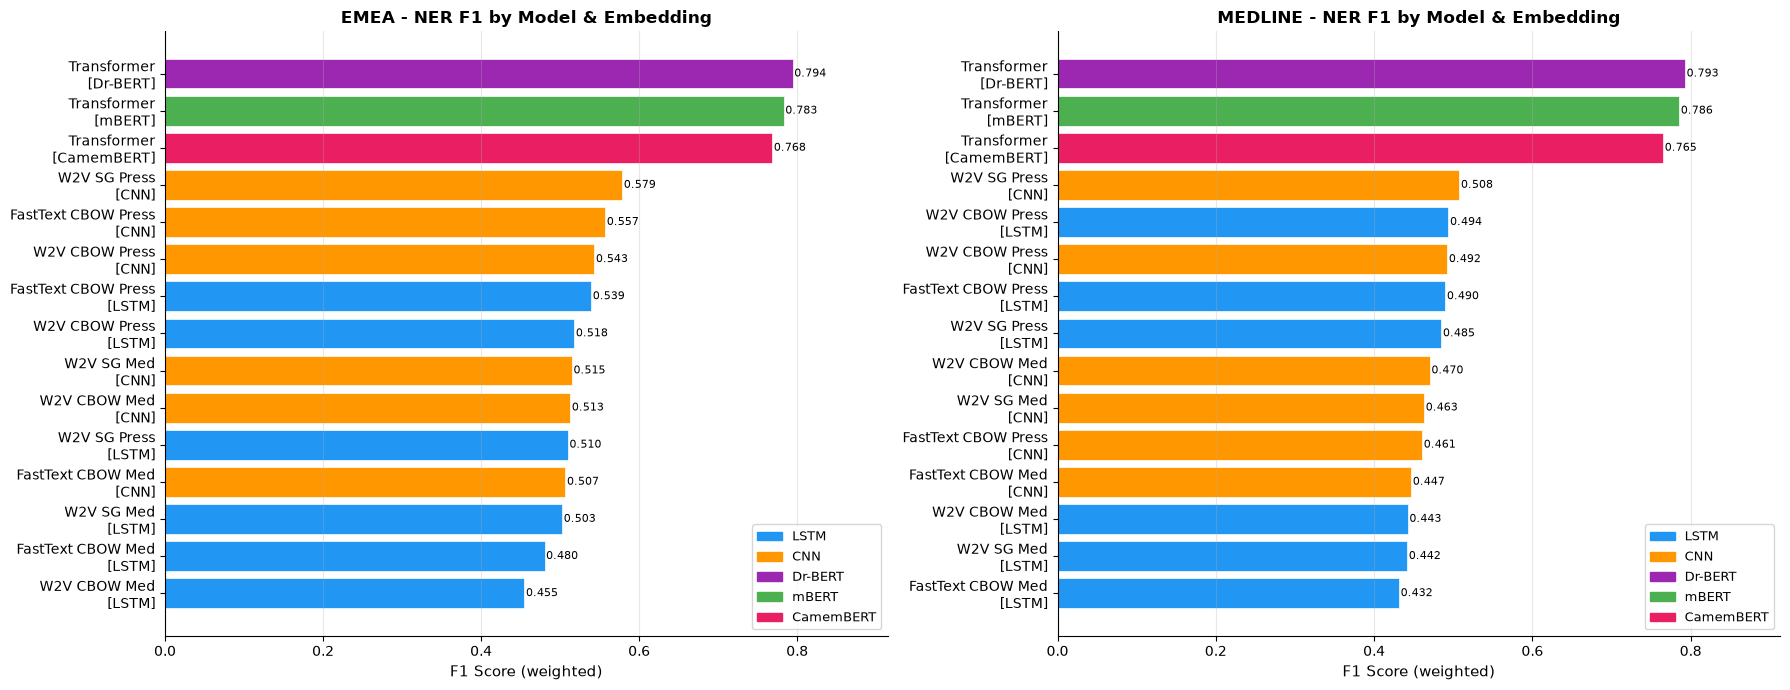

In [ ]:
from matplotlib.patches import Patch

colors = {
    'lstm': '#2196F3',
    'cnn': '#FF9800',
    'Dr-BERT/DrBERT-7GB': '#9C27B0',
    'bert-base-multilingual-uncased': '#4CAF50',
    'camembert-base': '#E91E63',
}

model_labels = {
    'lstm': 'LSTM',
    'cnn': 'CNN',
    'Dr-BERT/DrBERT-7GB': 'Dr-BERT',
    'bert-base-multilingual-uncased': 'mBERT',
    'camembert-base': 'CamemBERT',
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)

for ax, corpus_name in zip(axes, ['EMEA', 'MEDLINE']):
    sub = df[df['corpus'] == corpus_name].copy()

    # Use the readable model name in the bar labels
    sub['model_display'] = (
        sub['model']
        .map(model_labels)
        .fillna(sub['model'])
    )

    sub['bar_label'] = (
        sub['emb_label'].astype(str)
        + '\n['
        + sub['model_display'].astype(str)
        + ']'
    )

    sub = sub.sort_values('f1', ascending=True)

    bar_colors = [
        colors.get(model, '#607D8B')
        for model in sub['model']
    ]

    bars = ax.barh(
        sub['bar_label'],
        sub['f1'],
        color=bar_colors,
        edgecolor='white',
        linewidth=0.5
    )

    for bar, f1 in zip(bars, sub['f1']):
        ax.text(
            bar.get_width() + 0.002,
            bar.get_y() + bar.get_height() / 2,
            f'{f1:.3f}',
            va='center',
            fontsize=8
        )

    ax.set_xlabel('F1 Score (weighted)', fontsize=11)
    ax.set_title(
        f'{corpus_name} - NER F1 by Model & Embedding',
        fontsize=12,
        fontweight='bold'
    )
    ax.set_xlim(0, min(1.0, sub['f1'].max() + 0.12))
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    legend_items = [
        Patch(color=colors['lstm'], label='LSTM'),
        Patch(color=colors['cnn'], label='CNN'),
        Patch(color=colors['Dr-BERT/DrBERT-7GB'], label='Dr-BERT'),
        Patch(color=colors['bert-base-multilingual-uncased'], label='mBERT'),
        Patch(color=colors['camembert-base'], label='CamemBERT'),
    ]

    ax.legend(handles=legend_items, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Classical Models: Embedding Comparison

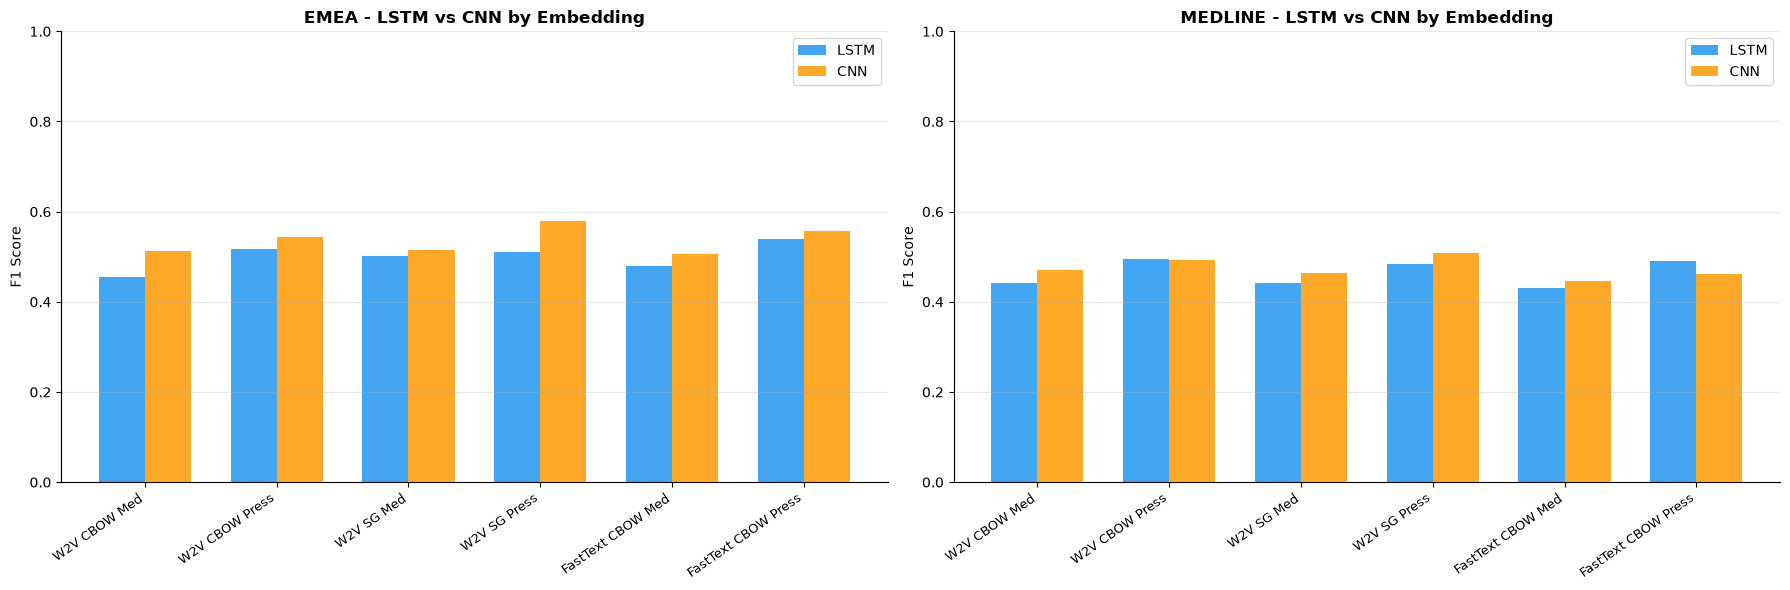

In [ ]:
classical = df[df['model_family'] == 'classical'].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

x_labels = [
    'W2V CBOW Med', 'W2V CBOW Press',
    'W2V SG Med', 'W2V SG Press',
    'FastText CBOW Med', 'FastText CBOW Press'
]

x = np.arange(len(x_labels))
width = 0.35

for ax, corpus_name in zip(axes, ['EMEA', 'MEDLINE']):
    sub = classical[classical['corpus'] == corpus_name]
    lstm_f1 = [sub[(sub['model']=='lstm') & (sub['emb_label']==lbl)]['f1'].values[0]
                if len(sub[(sub['model']=='lstm') & (sub['emb_label']==lbl)]) else 0
                for lbl in x_labels]
    cnn_f1  = [sub[(sub['model']=='cnn')  & (sub['emb_label']==lbl)]['f1'].values[0]
                if len(sub[(sub['model']=='cnn')  & (sub['emb_label']==lbl)]) else 0
                for lbl in x_labels]

    ax.bar(x - width/2, lstm_f1, width, label='LSTM', color='#2196F3', alpha=0.85)
    ax.bar(x + width/2, cnn_f1,  width, label='CNN',  color='#FF9800', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('F1 Score')
    ax.set_title(f'{corpus_name} - LSTM vs CNN by Embedding', fontsize=12, fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 7. Medical vs Press Embeddings Comparison

**Question:** Do embeddings trained on medical corpora outperform those trained on press corpora for this medical NER task?

In [ ]:
# Pairs: (med_label, press_label) per model type
pairs = [
    ('W2V CBOW Med',       'W2V CBOW Press'),
    ('W2V SG Med',         'W2V SG Press'),
    ('FastText CBOW Med',  'FastText CBOW Press'),
]

for corpus_name in ['EMEA', 'MEDLINE']:
    print(f'\n=== {corpus_name} ===')
    print(f'{"Embedding":<22} {"Model":<6} {"Med F1":>8} {"Press F1":>10} {"Delta (Med-Press)":>14}')
    print('-' * 65)
    sub = classical[classical['corpus'] == corpus_name]
    for med_lbl, press_lbl in pairs:
        emb_base = med_lbl.replace(' Med', '')
        for mdl in ['lstm', 'cnn']:
            med_row   = sub[(sub['model']==mdl) & (sub['emb_label']==med_lbl)]
            press_row = sub[(sub['model']==mdl) & (sub['emb_label']==press_lbl)]
            if med_row.empty or press_row.empty:
                continue
            med_f1   = med_row['f1'].values[0]
            press_f1 = press_row['f1'].values[0]
            delta = med_f1 - press_f1
            marker = 'Med wins' if delta > 0.005 else ('Press wins' if delta < -0.005 else 'tie')
            print(f'{emb_base:<22} {mdl:<6} {med_f1:>8.4f} {press_f1:>10.4f} {delta:>+8.4f}  {marker}')


=== EMEA ===
Embedding              Model    Med F1   Press F1 Delta (Med-Press)
-----------------------------------------------------------------
W2V CBOW               lstm     0.4548     0.5179  -0.0631  Press wins
W2V CBOW               cnn      0.5128     0.5433  -0.0304  Press wins
W2V SG                 lstm     0.5026     0.5098  -0.0072  Press wins
W2V SG                 cnn      0.5149     0.5786  -0.0637  Press wins
FastText CBOW          lstm     0.4802     0.5393  -0.0591  Press wins
FastText CBOW          cnn      0.5067     0.5571  -0.0504  Press wins

=== MEDLINE ===
Embedding              Model    Med F1   Press F1 Delta (Med-Press)
-----------------------------------------------------------------
W2V CBOW               lstm     0.4426     0.4940  -0.0514  Press wins
W2V CBOW               cnn      0.4704     0.4925  -0.0220  Press wins
W2V SG                 lstm     0.4419     0.4850  -0.0431  Press wins
W2V SG                 cnn      0.4633     0.5078  -0.0445  Pr

## 8. Transformer vs Classical: Best Results

In [ ]:
summary_rows = []
for corpus_name in ['EMEA', 'MEDLINE']:
    sub = df[df['corpus'] == corpus_name]

    best_lstm = sub[sub['model']=='lstm'].sort_values('f1', ascending=False).head(1)
    best_cnn  = sub[sub['model']=='cnn'].sort_values('f1',  ascending=False).head(1)
    transformers_sub = sub[~sub['model'].isin(['lstm','cnn'])]
    best_trans = transformers_sub.sort_values('f1', ascending=False).head(1) if not transformers_sub.empty else pd.DataFrame()

    for row, label in [(best_lstm, 'Best LSTM'), (best_cnn, 'Best CNN'), (best_trans, 'Best Transformer')]:
        if not row.empty:
            summary_rows.append({
                'Corpus': corpus_name,
                'Category': label,
                'Model/Embedding': f"{row['model'].values[0]} + {row['emb_label'].values[0]}",
                'F1': row['f1'].values[0],
                'Precision': row['precision'].values[0],
                'Recall': row['recall'].values[0],
            })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,Corpus,Category,Model/Embedding,F1,Precision,Recall
0,EMEA,Best LSTM,lstm + FastText CBOW Press,0.5393,0.5537,0.5256
1,EMEA,Best CNN,cnn + W2V SG Press,0.5786,0.5860,0.5713
2,EMEA,Best Transformer,Dr-BERT/DrBERT-7GB + Transformer,0.7942,0.8065,0.7823
3,MEDLINE,Best LSTM,lstm + W2V CBOW Press,0.4940,0.5093,0.4796
4,MEDLINE,Best CNN,cnn + W2V SG Press,0.5078,0.5190,0.4970
5,MEDLINE,Best Transformer,Dr-BERT/DrBERT-7GB + Transformer,0.7928,0.8067,0.7794


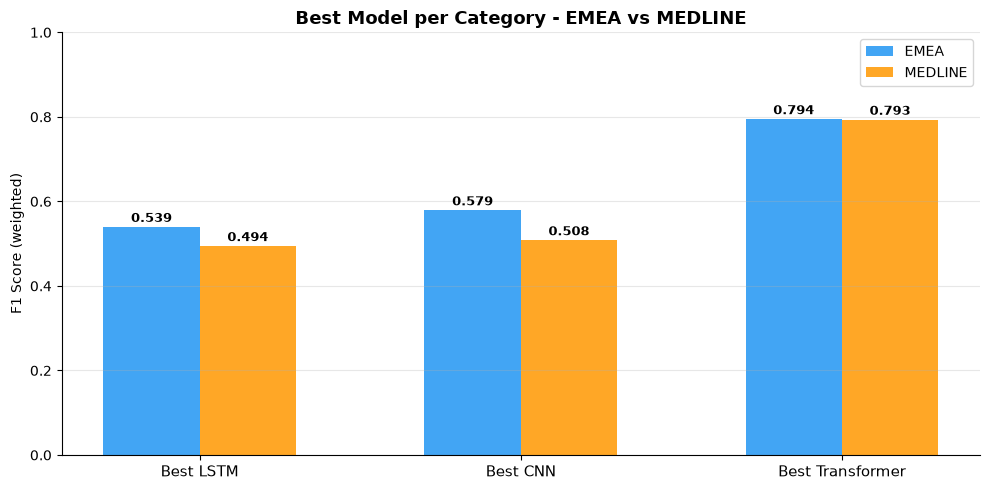

In [ ]:
# Grouped bar: Best LSTM / CNN / Transformer per corpus
fig, ax = plt.subplots(figsize=(10, 5))
categories = ['Best LSTM', 'Best CNN', 'Best Transformer']
corpora_plot = ['EMEA', 'MEDLINE']

x = np.arange(len(categories))
width = 0.3
palette = ['#2196F3', '#FF9800']

for i, corpus_name in enumerate(corpora_plot):
    vals = []
    for cat in categories:
        row = summary_df[(summary_df['Corpus']==corpus_name) & (summary_df['Category']==cat)]
        vals.append(row['F1'].values[0] if not row.empty else 0)
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=corpus_name, color=palette[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylabel('F1 Score (weighted)')
ax.set_title('Best Model per Category - EMEA vs MEDLINE', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 10. Discussion & Answers

### Q1: Which model provides the best performance on each dataset?

As shown in the results table, the best classical configuration on both datasets is the **CNN initialized with Word2Vec Skip-gram from the press corpus** (`w2v_sg_press`). It reaches $F_1 = 0.5786$ on EMEA and $F_1 = 0.5078$ on MEDLINE.

- **Best classical model:** Precision/recall are `0.5860/0.5713` on EMEA and `0.5190/0.4970` on MEDLINE. The relatively close values indicate a balanced result rather than an advantage caused by precision or recall alone. The lower MEDLINE score suggests more difficulty recovering complete entity spans in the more varied research-text setting.
- **CNN versus BiLSTM:** The best BiLSTM reaches $F_1 = 0.5393$ on EMEA and `0.4940` on MEDLINE, so the CNN gains `0.0393` and `0.0138`, respectively. Parallel convolutional filters detect short lexical patterns and local boundary cues directly; the smaller MEDLINE gain suggests that more heterogeneous text reduces the benefit of purely local features.

### Q2: Why do press embeddings outperform medical embeddings?

Embeddings learned from general press text consistently beat embeddings trained on the domain-specific medical corpus, with an average improvement of approximately `+0.04` to `+0.06` $F_1$ across the classical algorithms.

- **Corpus size outweighs domain match at small scale:** The press corpus contains roughly 1.25 million tokens across 38,500 sentences, compared with 52,000 tokens across 3,021 medical sentences. With `min_count = 1`, rare medical terms receive noisy and under-converged updates.
- **General context words matter for NER:** Entity spans are often marked by regular grammatical patterns such as *le patient presente un...*, *traitement par...*, and *en raison de...*. These connective-word representations are learned more reliably from the larger, syntactically varied press corpus.
- **Subword coverage is not sufficient alone:** FastText helps with lexical sparsity through character $n$-grams, but a very small corpus still produces high-variance subword statistics.

In summary, data volume dominates domain specialization when the specialized corpus is much smaller. Domain-specific embeddings require large-scale domain text to realize their advantage.

### Q3: How do the classical models compare with Transformers?

Comparing classical models with Transformers reveals a substantial performance gap:

- Transformers outperform the best classical model (CNN + `w2v_sg_press`) by more than `+0.21` $F_1$ on EMEA (`0.7942` vs. `0.5786`) and nearly `+0.29` on MEDLINE (`0.7928` vs. `0.5078`).
- **Contextualization:** Static embeddings assign one fixed vector to each word, whereas Transformers compute dynamic contextual representations through self-attention, helping resolve clinical polysemy and long-range dependencies.
- **Domain pre-training at scale:** DrBERT was pre-trained on more than 7GB of French biomedical text, combining domain specialization with sufficient scale and explaining its leading performance.
- **Model ranking:** DrBERT achieves $F_1 = 0.7942$ on EMEA and `0.7928` on MEDLINE, followed by mBERT (`0.7829` and `0.7855`) and CamemBERT (`0.7684` and `0.7652`).